# Query Generator Token Length Analysis

Measures the token length of fully-rendered `query_generation_prompt_r9.j2` inputs for every chunk in `danish_final_cluster` that has at least one explicit context chunk (i.e., the same filter used by `QueryGenerator.generate`).

Tokenizer: **o200k_base** (tiktoken name for the o200k / harmony family used by gpt-oss-120b).

In [1]:
import json
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
from jinja2 import Environment, FileSystemLoader, select_autoescape

import sys
sys.path.insert(0, '..')
from lcr.config import PROMPTS_DIR, RAW_DATA_DIR

2026-05-12 10:12:49.783 | INFO     | lcr.config:<module>:12 - PROJ_ROOT path is: /Users/m-proj/repositories/long-context-retrieval


In [2]:
tokenizer = tiktoken.get_encoding("o200k_base")

jinja_env = Environment(
    loader=FileSystemLoader(str(PROMPTS_DIR)),
    autoescape=select_autoescape()
)
template = jinja_env.get_template("query_generation_prompt_r9.j2")

# Static template cost (no variable content)
empty_prompt = template.render(chunk="", context_chunks="", impl_context_chunks="")
static_tokens = len(tokenizer.encode(empty_prompt))
print(f"Static template tokens (no variable content): {static_tokens}")

Static template tokens (no variable content): 3974


In [4]:
# Load all raw chunks from danish_final_cluster
raw_dir = RAW_DATA_DIR / "danish_final_cluster"
jsonl_files = glob.glob(str(raw_dir / "cluster_*" / "*" / "chunks.jsonl"))
print(f"Found {len(jsonl_files)} JSONL files:")
for f in sorted(jsonl_files):
    print(" ", f)

raw_lookup: dict[str, dict] = {}
for path in jsonl_files:
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                raw_lookup[rec["chunk_id"]] = rec

print(f"\nTotal chunks loaded: {len(raw_lookup)}")

Found 7 JSONL files:
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_A/almenboligloven/chunks.jsonl
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_A/barnetslov/chunks.jsonl
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_A/serviceloven/chunks.jsonl
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_B/aaregnskabsloven/chunks.jsonl
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_B/erhversfondsloven/chunks.jsonl
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_B/selskabsloven/chunks.jsonl
  /Users/m-proj/repositories/long-context-retrieval/data/raw/danish_final_cluster/cluster_T/straffeloven/chunks.jsonl

Total chunks loaded: 7743


In [ ]:
raw_lookup.values().get()

TypeError: 'dict_values' object is not subscriptable

In [24]:
# count how many of these chunks have a non-empty "context_chunks" field
non_empty_context_chunks = sum(1 for rec in raw_lookup.values() if rec.get("explicit_context_chunks"))
print(f"Chunks with non-empty 'expliciti_context_chunks': {non_empty_context_chunks}")

Chunks with non-empty 'expliciti_context_chunks': 3111


In [5]:
# Reproduce context-string building from DataFormatter.get_chunks_with_context
# context_col = "explicit_context_chunks", impl_context_col = "implicit_context_chunks"

def build_context_strings(source_chunk: dict, lookup: dict) -> tuple[str, str]:
    """Returns (context_chunks_str, impl_context_chunks_str) for the given chunk."""
    context_col = "explicit_context_chunks"
    impl_context_col = "implicit_context_chunks"

    context_ids: list[str] = source_chunk.get(context_col, [])

    # --- explicit context of the target chunk ---
    target_explicit_context = []
    for cid in context_ids:
        if cid in lookup:
            ctx = lookup[cid]
            target_explicit_context.append(f"{ctx['chunk']} (chunk_id: {ctx['chunk_id']})")
    target_explicit_context_str = " \n ".join(target_explicit_context)

    # --- implicit context of the context chunks (deduped) ---
    context_implicit_context: dict[str, list[str]] = {}
    for cid in context_ids:
        if cid in lookup:
            ctx = lookup[cid]
            for impl_id in ctx.get(impl_context_col, []):
                if impl_id in lookup:
                    text = lookup[impl_id]["chunk"]
                    if impl_id not in context_implicit_context:
                        context_implicit_context[text] = []
                    context_implicit_context[text].append(cid)

    context_implicit_context_str = ""
    for impl_text, owning_ids in context_implicit_context.items():
        context_implicit_context_str += (
            f"Chunks with chunk_id: {', '.join(owning_ids)} have the implicit context "
            f"(neighboring chunks): {impl_text} \n"
        )

    context = target_explicit_context_str + "\n\n" + context_implicit_context_str

    # --- implicit context of the target chunk itself ---
    impl_ids = source_chunk.get(impl_context_col, [])
    impl_context = " \n ".join(
        lookup[iid]["chunk"] for iid in impl_ids if iid in lookup
    )

    return context, impl_context

In [5]:
# Compute token lengths for all chunks that have at least one explicit context chunk
rows = []
skipped = 0

for chunk_id, record in raw_lookup.items():
    if not record.get("explicit_context_chunks"):  # same filter as QueryGenerator
        skipped += 1
        continue

    context_chunks_str, impl_context_chunks_str = build_context_strings(record, raw_lookup)

    if not context_chunks_str:  # double-check: formatter skips empty context
        skipped += 1
        continue

    prompt = template.render(
        chunk=record["chunk"],
        context_chunks=context_chunks_str,
        impl_context_chunks=impl_context_chunks_str,
    )
    n_tokens = len(tokenizer.encode(prompt))
    doc_id = chunk_id.split("_")[0]
    rows.append({"chunk_id": chunk_id, "doc_id": doc_id, "n_tokens": n_tokens})

df = pd.DataFrame(rows)
print(f"Chunks with context (processed): {len(df)}")
print(f"Chunks skipped (no context):     {skipped}")

Chunks with context (processed): 3111
Chunks skipped (no context):     4632


In [6]:
# Summary statistics
print("=== Token length distribution (o200k_base) ===")
print(df["n_tokens"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())
print()
print(f"MAX  : {df['n_tokens'].max():,}")
max_row = df.loc[df["n_tokens"].idxmax()]
print(f"  chunk_id : {max_row['chunk_id']}")
print(f"  doc_id   : {max_row['doc_id']}")

=== Token length distribution (o200k_base) ===
count     3111.000000
mean      6265.666988
std       3296.716739
min       4048.000000
50%       5485.000000
90%       8345.000000
95%      10541.000000
99%      17939.900000
max      86514.000000

MAX  : 86,514
  chunk_id : selskabsloven_§228_stk1
  doc_id   : selskabsloven


In [7]:
# Per-document max
per_doc = (
    df.groupby("doc_id")["n_tokens"]
    .agg(["max", "mean", "count"])
    .rename(columns={"max": "max_tokens", "mean": "mean_tokens", "count": "n_chunks"})
    .sort_values("max_tokens", ascending=False)
    .round(0)
)
per_doc["max_tokens"] = per_doc["max_tokens"].astype(int)
per_doc["n_chunks"] = per_doc["n_chunks"].astype(int)
print(per_doc.to_string())

                   max_tokens  mean_tokens  n_chunks
doc_id                                              
selskabsloven           86514       6185.0       700
aaregnskabsloven        74489       6909.0       398
serviceloven            30875       6325.0       575
erhversfondsloven       24464       5410.0       176
barnetslov              23762       5938.0       376
almenboligloven         23196       6805.0       540
straffeloven            14527       5541.0       346


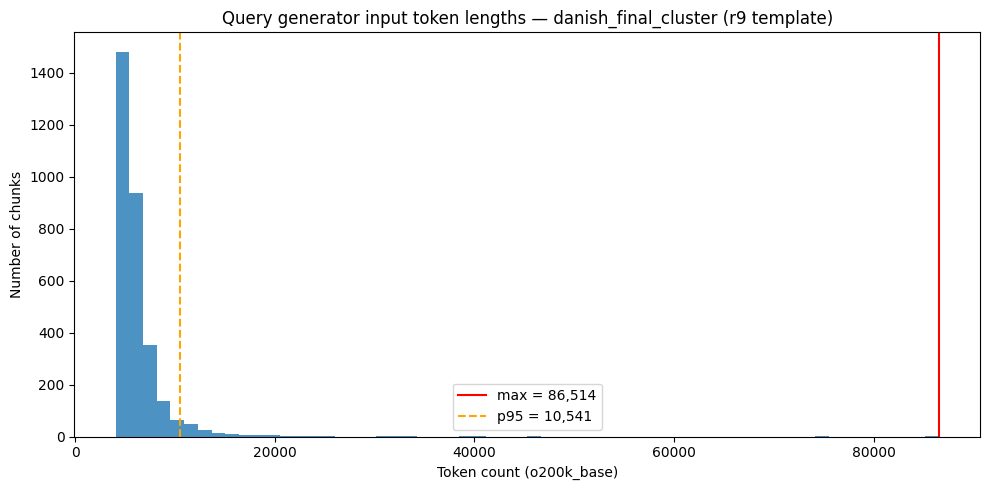

In [8]:
# Distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["n_tokens"], bins=60, edgecolor="none", alpha=0.8)
ax.axvline(df["n_tokens"].max(), color="red", linewidth=1.5, label=f"max = {df['n_tokens'].max():,}")
ax.axvline(df["n_tokens"].quantile(0.95), color="orange", linewidth=1.5, linestyle="--",
           label=f"p95 = {int(df['n_tokens'].quantile(0.95)):,}")
ax.set_xlabel("Token count (o200k_base)")
ax.set_ylabel("Number of chunks")
ax.set_title("Query generator input token lengths — danish_final_cluster (r9 template)")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# print below this longest-ever chunk for reference
print("\n=== Longest chunk with context (for reference) ===")
print(f"Chunk ID: {max_row['chunk_id']}")
print(f"Document ID: {max_row['doc_id']}")
print(f"Token count: {max_row['n_tokens']}")
print("\nChunk text:")
print(raw_lookup[max_row["chunk_id"]]["chunk"])



=== Longest chunk with context (for reference) ===
Chunk ID: selskabsloven_§228_stk1
Document ID: selskabsloven
Token count: 86514

Chunk text:
§ 228. Når der af Erhvervsstyrelsen er truffet beslutning om, at et kapitalselskab skal tvangsopløses, kan der ikke træffes beslutning om ændring af de registrerede forhold vedrørende kapitalselskabet bortset fra følgende:
1) Indsættelse af en likvidator udnævnt af skifteretten, jf. § 227, stk. 3, 1. pkt.
2) Ændring af en likvidator udnævnt af skifteretten.
3) Indsættelse af en revisor udnævnt af skifteretten, jf. § 227, stk. 3, 2. pkt.
4) Ændring af en revisor udnævnt af skifteretten.
5) Genoptagelse, jf. § 232.
6) Fusion, jf. §§ 236-253, jf. dog stk. 2.
7) Spaltning, jf. §§ 254-270, jf. dog stk. 2.
8) Grænseoverskridende fusion, jf. §§ 271-290 og 311-317, jf. dog stk. 2.
9) Grænseoverskridende spaltning, jf. §§ 291-311 og § 318, jf. dog stk. 2.
